# TP 2 : moindres carrés, perceptron, régression logistique

Trois façons d'ajuster la même frontière, et ce que chacune fait des points sur lesquels personne
n'hésite.

## 2.0 Une décision à prendre sur 569 biopsies

569 biopsies mammaires, chacune décrite par deux mesures de la tumeur : sa **surface moyenne** et
sa **concavité moyenne**. 212 sont malignes. Il faut décider, pour chaque biopsie, entre *maligne*
et *bénigne* ; et les deux erreurs ne se paient pas au même prix.

Un classifieur linéaire lit le **signe** d'un score :

$$h_w(x) = \operatorname{sign}(w^T x), \qquad w^T x = 0 \ \text{ est la frontière} .$$

Avec deux mesures, cette frontière est une droite. Les deux colonnes sont centrées et réduites,
pour qu'un coefficient de chacune se lise sur la même échelle.

**Q1.** Deux erreurs sont possibles : annoncer *bénigne* pour une tumeur maligne, ou annoncer
*maligne* pour une tumeur bénigne. Laquelle des deux coûte le plus cher ici ? Un taux de bonnes
réponses, qui compte les deux erreurs au même prix, suffit-il à juger ce classifieur ?

**Réponse attendue :** Manquer une tumeur maligne coûte incomparablement plus cher : un cancer non traité, contre des
examens complémentaires et de l'angoisse pour une fausse alerte. Les deux erreurs ne sont pas
interchangeables.

Non, un taux de bonnes réponses ne suffit donc pas : il additionne les deux erreurs à poids égal, et
reste flatteur pour un classifieur qui se protège des fausses alertes en manquant des cancers. Il
faut compter séparément les malignes manquées et les fausses alertes.

Attention, des classes presque équilibrées (212 malignes sur 569) ne rendent pas la justesse
suffisante pour autant. L'équilibre des classes n'est pas la question ici ; c'est l'asymétrie des
coûts qui invalide un score unique, et elle ne se corrige pas en rééquilibrant les classes.

*Pour aller plus loin :* un modèle qui ne rend qu'une classe n'offre aucun réglage. Un score, ou
mieux une probabilité, permet de déplacer après coup le point de bascule du côté des malignes
détectées ; ni les moindres carrés ni le perceptron ne le permettent.

569 biopsies, dont 212 malignes
surface moyenne : de 144 à 2501


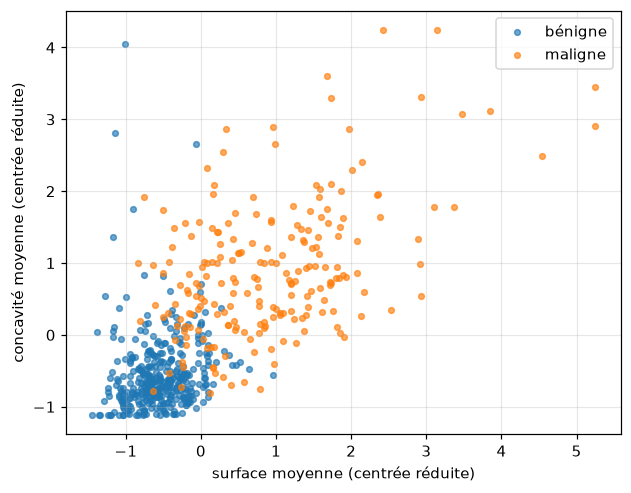

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

np.seterr(all="ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

cancer = load_breast_cancer()
columns = [list(cancer.feature_names).index(name) for name in ("mean area", "mean concavity")]
X = StandardScaler().fit_transform(cancer.data[:, columns])
malignant = (cancer.target == 0).astype(int)       # the dataset codes 0 as malignant
t = np.where(malignant == 1, 1.0, -1.0)            # targets for the least-squares fit
area = cancer.data[:, columns[0]]

print(f"{len(X)} biopsies, dont {malignant.sum()} malignes")
print(f"surface moyenne : de {area.min():.0f} à {area.max():.0f}")


def design_matrix(X):
    return np.hstack([np.ones((len(X), 1)), X])


def boundary(ax, w, label, color, style="-"):
    """Draw the line w0 + w1 x1 + w2 x2 = 0."""
    x1 = np.array(ax.get_xlim())
    ax.plot(x1, -(w[0] + w[1] * x1) / w[2], style, color=color, lw=2, label=label)


fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(*X[malignant == 0].T, s=14, alpha=0.65, label="bénigne")
ax.scatter(*X[malignant == 1].T, s=14, alpha=0.65, label="maligne")
ax.set_xlabel("surface moyenne (centrée réduite)")
ax.set_ylabel("concavité moyenne (centrée réduite)")
ax.legend()
plt.show()

## 2.1 Les moindres carrés comme classifieur

On code les classes $+1$ et $-1$, on ajuste par moindres carrés comme s'il s'agissait d'une
régression, et on prédit le signe du score :

$$w = (X^T X)^{-1} X^T t, \qquad \hat y = \operatorname{sign}(w^T x).$$

Aucune itération, aucun taux d'apprentissage : une forme close.

**Q2.** Un patient dont la tumeur est énorme obtient un score $w^T x$ de $+5$, pour une cible de
$+1$ ; un autre, de même cible $+1$, obtient $-3$, donc du mauvais côté de la frontière. Que vaut la
contribution de chacun à la somme des carrés, et qu'en concluez-vous sur ce que cette somme
distingue ?

**Réponse attendue :** Les deux contributions valent la même chose : $(5 - 1)^2 = 16$ pour le point de score $+5$, et
$(-3 - 1)^2 = 16$ pour celui de score $-3$, qui est pourtant franchement du mauvais côté de la
frontière. La somme des carrés ne distingue donc pas « très bien classé » de « mal classé du même
écart » : elle ne mesure qu'une distance à la cible $\pm 1$, et le signe du résidu disparaît au
carré.

Attention, la contribution du premier point ne vaut pas 0 sous prétexte qu'il est bien classé : ce
serait confondre l'erreur de classement, nulle ici, avec le résidu quadratique, qui vaut 16. Rien
dans la somme des carrés ne parle de classement.

*Pour aller plus loin :* les moindres carrés vont donc traiter le point de score $+5$ comme une
erreur à corriger, en déplaçant $w$ pour ramener ce score vers $+1$ : soit en rapprochant la
frontière de lui, soit en réduisant la norme de $w$. Le point le plus certain du jeu tire ainsi la
frontière vers lui, et vous allez le voir à l'œuvre sur les biopsies.

moindres carrés sur les 569 biopsies : justesse 0.889, 57 malignes manquées sur 212, 6 fausses alertes


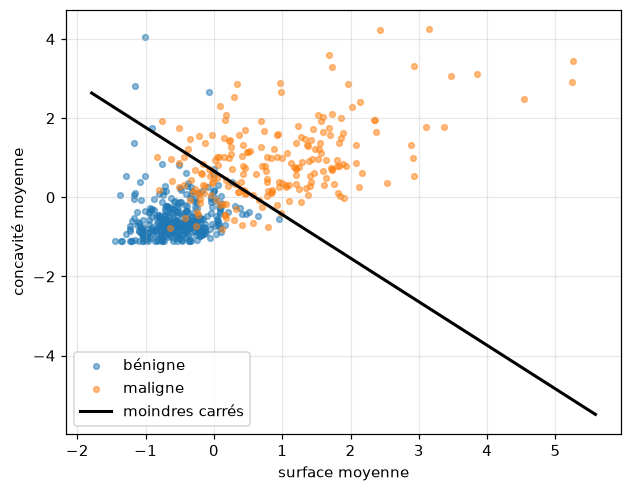

In [2]:
def least_squares_classifier(X, t):
    return np.linalg.lstsq(design_matrix(X), t, rcond=None)[0]


def classify(X, w):
    return np.sign(design_matrix(X) @ w)


def counts(t_true, t_predicted):
    """Missed malignant tumours, false alarms, and accuracy."""
    missed = int(np.sum((t_predicted < 0) & (t_true > 0)))
    false_alarms = int(np.sum((t_predicted > 0) & (t_true < 0)))
    return missed, false_alarms, float(np.mean(t_predicted == t_true))


w_ls = least_squares_classifier(X, t)
assert np.allclose(w_ls, np.linalg.lstsq(design_matrix(X), t, rcond=None)[0])
assert set(np.unique(classify(X, w_ls))) <= {-1.0, 1.0}

missed, false_alarms, accuracy = counts(t, classify(X, w_ls))
print(f"moindres carrés sur les 569 biopsies : justesse {accuracy:.3f}, "
      f"{missed} malignes manquées sur {int((t > 0).sum())}, {false_alarms} fausses alertes")

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(*X[malignant == 0].T, s=14, alpha=0.5, label="bénigne")
ax.scatter(*X[malignant == 1].T, s=14, alpha=0.5, label="maligne")
boundary(ax, w_ls, "moindres carrés", "black")
ax.set_xlabel("surface moyenne")
ax.set_ylabel("concavité moyenne")
ax.legend()
plt.show()

## 2.2 Les cas sur lesquels personne n'hésite

Parmi ces 569 tumeurs, il y a les **10 % les plus grosses** et les **10 % les plus petites** :
celles dont le diagnostic ne fait aucun doute. On les met de côté (non pas comme des données
aberrantes, elles sont parfaitement correctes) et on demande au modèle ce qui l'intéresse
vraiment : les **454 cas restants**, ceux où la décision se joue.

Deux ajustements à comparer, tous deux **évalués sur ces 454 cas** :

- le premier entraîné sur les 569 biopsies, cas évidents inclus,
- le second entraîné sur les 454 seules.

**Q3.** Les 115 cas évidents sont loin de la frontière, du bon côté, et parfaitement classés : leur
score est donc très éloigné de la cible $\pm 1$. D'après Q2, leur contribution à la somme des carrés
est-elle petite ou grosse, et que risque-t-elle de coûter aux 454 cas du milieu ?

**Réponse attendue :** Grosse. Ces points sont inattaquables du point de vue du classement, mais leurs scores sont très
loin de $\pm 1$, donc leurs résidus au carré sont énormes, donc ils dominent la somme que les
moindres carrés minimisent.

Ce que cela coûte aux 454 cas du milieu : la frontière va se déplacer pour soulager les 115 cas
évidents, qui pèsent plus lourd dans la somme que les cas litigieux. Les moindres carrés achètent du
confort sur des points déjà gagnés, et le paient là où la décision se joue vraiment.

Attention, ce ne sont pas des données aberrantes. Il n'y a rien à nettoyer, rien de faux ; ce sont
des biopsies parfaitement correctes, et les mieux classées du jeu. C'est la perte qui est mal
choisie pour la tâche. Les mettre de côté n'est donc pas un nettoyage : c'est un montage qui rend
visible le poids qu'elles prennent dans la somme des carrés.

115 cas évidents, 454 cas ambigus dont 155 malignes

                         ajustement justesse sur les 454  malignes manquées  fausses alertes
      moindres carrés, tous les cas                0.866                 57                4
 moindres carrés, sans les évidents                0.901                 37                8
régression logistique, tous les cas                0.888                 33               18


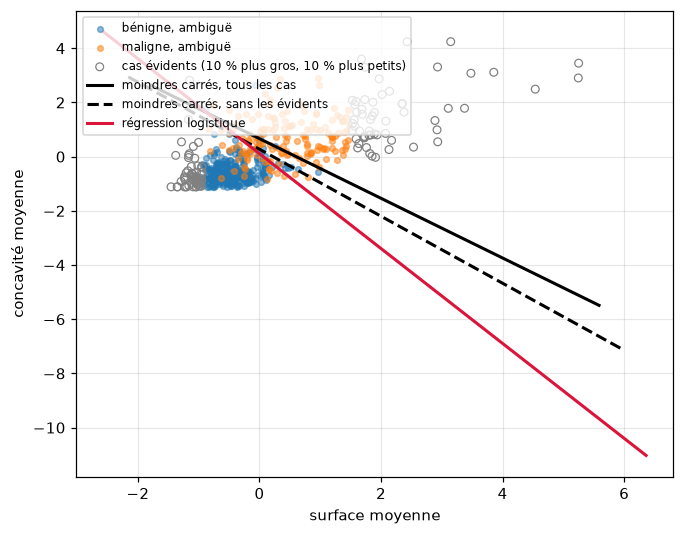

In [3]:
obvious = (area >= np.quantile(area, 0.9)) | (area <= np.quantile(area, 0.1))
ambiguous = ~obvious
print(f"{obvious.sum()} cas évidents, {ambiguous.sum()} cas ambigus "
      f"dont {int((t[ambiguous] > 0).sum())} malignes")

w_all = least_squares_classifier(X, t)
w_without = least_squares_classifier(X[ambiguous], t[ambiguous])

logistic = LogisticRegression(C=1e12, max_iter=5000).fit(X, malignant)
w_logistic = np.r_[logistic.intercept_, logistic.coef_[0]]

rows = []
for label, w in (("moindres carrés, tous les cas", w_all),
                 ("moindres carrés, sans les évidents", w_without),
                 ("régression logistique, tous les cas", w_logistic)):
    missed, false_alarms, accuracy = counts(t[ambiguous], classify(X[ambiguous], w))
    rows.append({"ajustement": label, "justesse sur les 454": accuracy,
                 "malignes manquées": missed, "fausses alertes": false_alarms})

assert rows[0]["malignes manquées"] > rows[1]["malignes manquées"]
print()
print(pd.DataFrame(rows).to_string(index=False, formatters={"justesse sur les 454": "{:.3f}".format}))

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(*X[ambiguous & (malignant == 0)].T, s=14, alpha=0.5, label="bénigne, ambiguë")
ax.scatter(*X[ambiguous & (malignant == 1)].T, s=14, alpha=0.5, label="maligne, ambiguë")
ax.scatter(*X[obvious].T, s=26, facecolors="none", edgecolors="gray", lw=0.8,
           label="cas évidents (10 % plus gros, 10 % plus petits)")
boundary(ax, w_all, "moindres carrés, tous les cas", "black")
boundary(ax, w_without, "moindres carrés, sans les évidents", "black", "--")
boundary(ax, w_logistic, "régression logistique", "crimson")
ax.set_xlabel("surface moyenne")
ax.set_ylabel("concavité moyenne")
ax.legend(fontsize=8, loc="upper left")
plt.show()

**Q4.** Dans le tableau, les deux premières lignes ne diffèrent que par les 115 cas évidents,
retirés de l'entraînement pour la seconde. La colonne `justesse sur les 454` passe de 0,866 à 0,901,
soit trois points et demi, pendant que les `malignes manquées` passent de 57 à 37 et les
`fausses alertes` de 4 à 8. Lequel de ces chiffres dit ce qui a changé pour les patientes ?

**Réponse attendue :** Les `malignes manquées` : 57 contre 37. Vingt cancers de plus, parmi les 454 cas ambigus, en
échange de points que le modèle classait déjà correctement.

La justesse, elle, ne passe que de 0,866 à 0,901, trois points et demi. C'est le point central :
un score global agrège les deux erreurs à poids égal, donc il masque un déplacement de frontière qui
échange des fausses alertes contre des cancers manqués. Ici les fausses alertes passent de 4 à 8
pendant que les manquées tombent de 57 à 37 ; il faut compter les deux erreurs séparément pour voir
ce qui s'est passé.

Attention, une justesse qui bouge à peine ne veut pas dire que les deux lignes sont équivalentes.
Quatre fausses alertes de plus contre vingt cancers détectés n'est pas un échange neutre, et aucun
des trois chiffres pris seul ne le dit ; c'est la paire manquées / fausses alertes qui le dit.

*Pour aller plus loin :* la troisième ligne du tableau, la régression logistique entraînée sur les
569 biopsies, n'en manque que 33 sans qu'on ait retiré quoi que ce soit de l'entraînement, au prix
de 18 fausses alertes contre 8. Elle obtient cela en cessant de punir les points dont le classement
ne fait aucun doute.

## 2.3 Le perceptron ne corrige que ses erreurs

Le perceptron ne mesure pas l'écart entre son score et une cible. Il ne compte que ses **erreurs** :

$$E(w) = -\sum_{i \in \mathcal{M}} y^{(i)}\, w^T x^{(i)}, \qquad
  \nabla_w E = -\sum_{i \in \mathcal{M}} y^{(i)} x^{(i)},$$

où $\mathcal{M}$ est l'ensemble des points mal classés. Un point bien classé ne contribue pas,
donc les cas évidents de tout à l'heure ne peuvent rien tirer. Exemple par exemple, la règle
devient :

$$\boxed{\ \text{si } y^{(i)} w^T x^{(i)} \le 0 : \quad w \leftarrow w + \alpha\, y^{(i)} x^{(i)}
  \quad \text{sinon : rien}\ }$$

On l'essaie sur deux problèmes à deux mesures : les pétales des iris. **Setosa contre versicolor**
d'abord, puis **versicolor contre virginica**.

**Q5.** Le perceptron s'arrête quand il ne fait plus d'erreur sur une époque entière. Sur un jeu où
aucune droite ne peut séparer les deux classes, la règle encadrée trouve-t-elle toujours un point à
corriger ? Qu'en concluez-vous sur l'arrêt de la boucle ?

**Réponse attendue :** Oui, toujours. Si aucune droite ne sépare les deux classes, alors quelle que soit la droite
courante il reste au moins un point mal classé, donc au moins une mise à jour à faire. La condition
d'arrêt « aucune erreur sur une époque entière » n'est jamais remplie : la boucle ne s'arrête pas
d'elle-même, et il faut lui imposer un nombre maximal d'époques.

Le cas séparable est l'autre moitié de l'histoire : là, l'arrêt est garanti en un nombre fini de
pas, c'est le théorème de convergence du perceptron.

Attention, laisser tourner plus longtemps ne règle rien dans le cas non séparable : le nombre
d'époques n'est pas le problème, aucune droite n'annule les erreurs, donc aucun nombre d'époques n'y
suffira.

*Pour aller plus loin :* même quand il s'arrête, la frontière rendue dépend de tout ce qui n'est pas
le problème : le $w$ initial, l'ordre de passage des exemples, le taux $\alpha$. Le perceptron
s'arrête au premier hyperplan qui sépare, pas au meilleur : rien dans son critère ne parle de la
distance aux points.

setosa contre versicolor         arrêt à l'époque 2
                                 erreurs par époque, 12 premières : [10, 0]
versicolor contre virginica      11 erreurs encore à l'époque 200
                                 erreurs par époque, 12 premières : [55, 30, 29, 37, 32, 30, 30, 20, 19, 31, 26, 13]


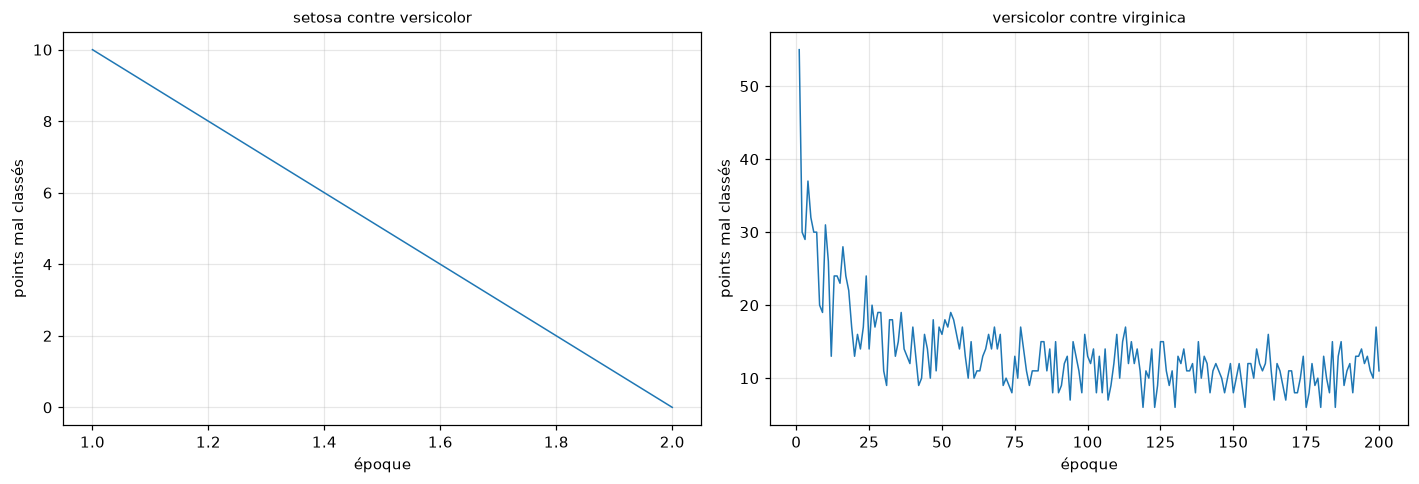

In [4]:
iris = load_iris()
petals = iris.data[:, 2:4]         # petal length, petal width


def perceptron(X, t, alpha=0.1, n_epochs=200, seed=0):
    """Returns the weights and the number of misclassified points at each epoch."""
    rng = np.random.default_rng(seed)
    A = design_matrix(X)
    w = np.zeros(A.shape[1])
    errors_per_epoch = []
    for _ in range(n_epochs):
        errors = 0
        for i in rng.permutation(len(A)):
            if t[i] * (A[i] @ w) <= 0:
                w = w + alpha * t[i] * A[i]
                errors += 1
        errors_per_epoch.append(errors)
        if errors == 0:
            break
    return w, errors_per_epoch


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (a, c, label) in zip(axes, [(0, 1, "setosa contre versicolor"),
                                    (1, 2, "versicolor contre virginica")]):
    mask = np.isin(iris.target, [a, c])
    X_pair = petals[mask]
    t_pair = np.where(iris.target[mask] == a, 1.0, -1.0)
    w_perceptron, errors = perceptron(X_pair, t_pair)
    stopped = "arrêt à l'époque %d" % len(errors) if errors[-1] == 0 else \
              "%d erreurs encore à l'époque %d" % (errors[-1], len(errors))
    print(f"{label:<32} {stopped}")
    print(f"{'':<32} erreurs par époque, 12 premières : {errors[:12]}")
    ax.plot(range(1, len(errors) + 1), errors, lw=1)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("époque")
    ax.set_ylabel("points mal classés")

assert len(perceptron(petals[iris.target != 2], np.where(iris.target[iris.target != 2] == 0, 1.0, -1.0))[1]) < 200
plt.tight_layout()
plt.show()

**Q6.** À gauche, la sortie indique un arrêt à l'époque 2 ; à droite, encore 11 erreurs à l'époque
200, et la figure montre un compte qui oscille sans jamais descendre à zéro. D'après Q5, qu'est-ce
que cela dit du jeu versicolor contre virginica, et qu'est-ce qui a arrêté la boucle de ce côté ?

**Réponse attendue :** Que versicolor et virginica ne se séparent pas par une droite sur ces deux mesures de pétale :
elles se recouvrent. D'après Q5, il reste alors toujours un point à corriger, et c'est ce que la
sortie montre : 55 erreurs au premier passage, puis 30, 29, 37, 32, 30… un compte qui oscille,
remonte parfois (corriger un point en dérègle d'autres) et ne descend jamais à zéro.

Ce qui a arrêté la boucle de ce côté est donc le plafond de 200 époques, pas la condition « plus
aucune erreur » : il reste 11 points mal classés au moment de l'interruption. À gauche, au
contraire, dix erreurs au premier passage puis zéro au second, et l'arrêt tombe de lui-même à
l'époque 2.

Attention, 11 erreurs restantes ne veut pas dire « c'est presque fini ». Le compte était déjà à 13 à
l'époque 12 : entre la douzième et la deux-centième, il a oscillé sans progresser. Et le $w$ livré
est celui qui se trouvait en mémoire au deux-centième passage : le plafond interrompt, il ne
sélectionne pas.

*Pour aller plus loin :* sur le problème de gauche non plus la frontière n'est pas la meilleure,
c'est la première qui sépare. D'autres droites séparent aussi, plus loin des deux nuages, donc plus
robustes sur de nouvelles fleurs ; chercher celle qui maximise la marge est ce que font les SVM.

## 2.4 Une activation lisse, et une probabilité

L'échelon du perceptron ne dit que « d'un côté ou de l'autre ». La **sigmoïde** remplace la
marche par une pente, et sa sortie se lit comme une probabilité :

$$\hat y = \sigma(w^T x) = \frac{1}{1 + e^{-w^T x}} \in (0, 1), \qquad y \in \{0, 1\} .$$

La perte n'est plus quadratique mais l'**entropie croisée** :

$$J(w) = -\frac{1}{m}\sum_{i=1}^{m}\Big[y^{(i)} \log \hat y^{(i)}
   + \big(1 - y^{(i)}\big)\log\big(1 - \hat y^{(i)}\big)\Big],$$

et son gradient se simplifie en une formule d'une lisibilité frappante, le **résidu fois
l'entrée** :

$$\boxed{\ \nabla_w J = \frac{1}{m}\sum_{i=1}^{m}\big(\hat y^{(i)} - y^{(i)}\big)\, x^{(i)}\ }$$

Chaque point tire sur $w$ **à proportion de son erreur**. Un point bien classé, dont $\hat y$ est
proche de $y$, ne tire presque pas : c'est exactement ce qui manquait aux moindres carrés. Il n'y a
pas de forme close, donc on descend.

**Q7.** Pour un cas évident avec $y = 1$ et un score $w^T x$ de 9, la sigmoïde donne un $\hat y$
presque égal à 1. Que vaut alors le résidu $\hat y - y$ de la formule encadrée, et que vaudrait-il si
$\hat y$ était le score 9 lui-même, comme chez les moindres carrés ?

**Réponse attendue :** Sous la sigmoïde, $\hat y \approx 1$ et $y = 1$, donc le résidu $\hat y - y$ vaut $\approx 0$ : ce
point ne tire pratiquement plus sur $w$. Si $\hat y$ était le score lui-même, il vaudrait 9 et le
résidu $9 - 1 = 8$ : huit fois le plus grand résidu que la sigmoïde puisse produire, sur une tumeur
dont la classe ne fait aucun doute.

La raison est que la sortie de la sigmoïde est bornée par 1, donc le résidu est borné par 1 quoi
qu'il arrive, alors que le score n'est pas borné : à $w^T x = 90$, le résidu de la seconde version
vaudrait 89, et il croît sans limite avec la certitude du classement. La perte quadratique punit la
confiance ; l'entropie croisée la récompense en cessant de s'en occuper.

Attention, le résidu ne vaut pas 0 dans les deux cas sous prétexte que le point est bien classé :
c'est vrai sous la sigmoïde seulement. Attention aussi au signe : la formule encadrée soustrait $y$
à $\hat y$, dans cet ordre, donc le résidu vaut ici $+8$ ; écrite dans l'autre sens, $y - \hat y$,
la même quantité vaut $-8$, avec la même taille et le sens opposé.

In [5]:
def sigmoid(z):
    return np.where(z >= 0, 1 / (1 + np.exp(-np.abs(z))), np.exp(-np.abs(z)) / (1 + np.exp(-np.abs(z))))


def cross_entropy(X, y, w):
    p = sigmoid(design_matrix(X) @ w)
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def cross_entropy_gradient(X, y, w):
    A = design_matrix(X)
    return A.T @ (sigmoid(A @ w) - y) / len(y)


def gradient_per_biopsy(X, y, w):
    """The same gradient, written as the mean over the m biopsies."""
    A = design_matrix(X)
    residuals = sigmoid(A @ w) - y
    return np.mean(residuals[:, None] * A, axis=0)

w_probe = np.array([0.3, -0.7, 0.5])
assert np.isclose(sigmoid(0.0), 0.5)
assert np.isclose(sigmoid(-50), 0.0, atol=1e-12) and np.isfinite(cross_entropy(X, malignant, w_probe))
assert np.allclose(cross_entropy_gradient(X, malignant, w_probe),
                   gradient_per_biopsy(X, malignant, w_probe))

w_gd = np.zeros(3)
history = []
for step in range(4000):
    w_gd = w_gd - 0.5 * cross_entropy_gradient(X, malignant, w_gd)
    history.append(cross_entropy(X, malignant, w_gd))

print(f"entropie croisée : descente {history[-1]:.4f}, "
      f"sklearn {cross_entropy(X, malignant, w_logistic):.4f}")
print(f"poids : descente {np.round(w_gd, 3)}, sklearn {np.round(w_logistic, 3)}")

probabilities = sigmoid(design_matrix(X) @ w_gd)
rows = []
for threshold in (0.5, 0.4, 0.3, 0.2):
    predicted = np.where(probabilities >= threshold, 1.0, -1.0)
    missed, false_alarms, accuracy = counts(t, predicted)
    rows.append({"seuil": threshold, "justesse": accuracy,
                 "malignes manquées": missed, "fausses alertes": false_alarms})
print()
print(pd.DataFrame(rows).to_string(index=False, formatters={"justesse": "{:.3f}".format}))

entropie croisée : descente 0.2020, sklearn 0.2020
poids : descente [-0.236  3.731  2.132], sklearn [-0.236  3.73   2.13 ]

 seuil justesse  malignes manquées  fausses alertes
   0.5    0.907                 33               20
   0.4    0.910                 24               27
   0.3    0.910                 16               35
   0.2    0.895                 10               50


**Q8.** Dans le tableau des seuils, le modèle est le même à chaque ligne : seul le seuil de
décision change. Les `malignes manquées` tombent de 33 au seuil 0,5 à 16 au seuil 0,3, pendant que
les `fausses alertes` montent de 20 à 35. Qu'est-ce qu'une probabilité permet de faire ici, que le
signe rendu par le perceptron ne permettrait pas ?

**Réponse attendue :** Elle permet de choisir le point de bascule après coup, sans rien réajuster : le $w$ est le même sur
les quatre lignes, seul change le niveau à partir duquel on annonce *maligne*. Le tableau le
montre : à 0,5 on manque 33 malignes pour 20 fausses alertes ; à 0,3, plus que 16 pour 35 ; à 0,2,
10 pour 50. Le perceptron ne rend qu'un signe : sa décision est déjà prise, et la déplacer
demanderait de réentraîner.

Attention, la colonne `justesse` ne désigne pas la bonne ligne. Elle vaut 0,907, puis 0,910, 0,910
et 0,895 (pratiquement plate) pendant que les malignes manquées passent de 33 à 10. Le seuil ne
s'apprend pas et ne s'optimise pas contre un score global : il se décide en regardant ce qu'on
accepte de payer.

*Pour aller plus loin :* vu le coût des deux erreurs ici, un seuil bas se défend : 0,3 divise par
deux le nombre de cancers manqués contre quinze fausses alertes de plus. Mais ce tableau est calculé
sur les 569 biopsies qui ont servi à l'ajustement : il illustre le mécanisme, il ne fixe pas le
seuil à livrer, qui se choisit sur des données mises de côté.

## 2.5 Trois classes, et celle du milieu qui disparaît

Trois espèces d'iris, et deux mesures : longueur du sépale et largeur du pétale. On étend les
moindres carrés au multiclasse en donnant à chaque classe **sa colonne de cibles**, valant 1 pour
ses exemples et 0 pour les autres (un codage **one-hot**), puis on prédit la classe de plus grand
score :

$$W = (X^T X)^{-1} X^T Y, \qquad \hat y = \arg\max_k \big(W^T x\big)_k .$$

La softmax fait la même chose en remplaçant l'identité par une distribution :

$$\hat y_c = \frac{\exp(w_c^T x)}{\sum_j \exp(w_j^T x)} .$$

**Q9.** Les trois espèces se rangent presque en ligne le long de la largeur de pétale : setosa, puis
versicolor, puis virginica. Le score de versicolor est une fonction linéaire de cette largeur :
peut-il être haut au milieu et bas aux deux bouts ? Qu'en concluez-vous sur l'$\arg\max$ pour cette
classe ?

**Réponse attendue :** Non. Une fonction linéaire de la largeur de pétale est monotone : elle monte, elle descend, ou elle
est plate, mais elle ne fait pas de bosse. Le score de versicolor ne peut donc pas être à la fois
au-dessus de celui de setosa du côté des petits pétales et au-dessus de celui de virginica du côté
des grands : la classe du milieu est prise en sandwich, et l'$\arg\max$ ne la désignera presque
jamais.

La colonne de versicolor dans $W$ est un ajustement linéaire vers une cible qui vaut 1 au centre et
0 aux deux bouts, exactement la forme qu'un modèle linéaire ne sait pas produire. Le score de
versicolor finit donc à peu près plat, et un score plat perd partout contre un score croissant d'un
côté et décroissant de l'autre.

Attention, des poids mieux choisis n'y changeraient rien, et l'$\arg\max$ n'est pas en cause. Le
défaut n'est ni dans le réglage ni dans la comparaison des scores, il est dans la forme des
fonctions comparées : trois droites, dont une qui devrait culminer au milieu.

            vraies  prédites, moindres carrés  prédites, softmax
setosa          50                         60                 50
versicolor      50                          4                 52
virginica       50                         86                 48

justesse : moindres carrés 0.693, softmax 0.960


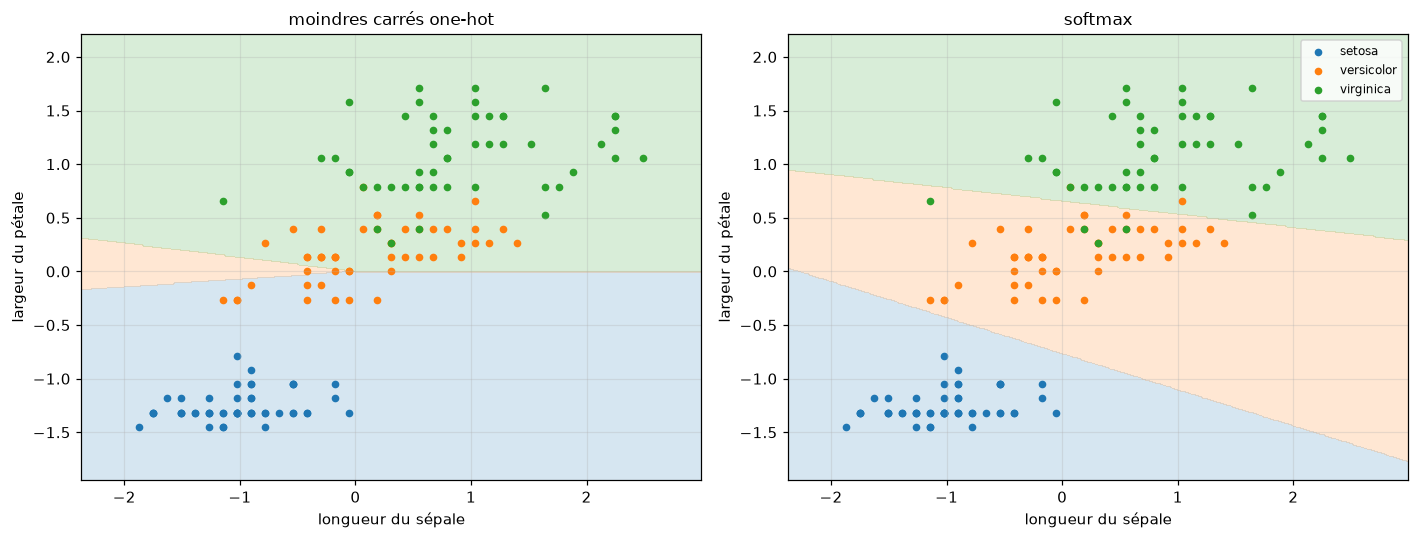

In [6]:
pair = [list(iris.feature_names).index(n) for n in ("sepal length (cm)", "petal width (cm)")]
X_iris = StandardScaler().fit_transform(iris.data[:, pair])
y_iris = iris.target
species = list(iris.target_names)


def one_hot(y, n_classes):
    return np.eye(n_classes)[y]


def least_squares_multiclass(X, y, n_classes):
    A = design_matrix(X)
    return np.linalg.lstsq(A, one_hot(y, n_classes), rcond=None)[0]


W = least_squares_multiclass(X_iris, y_iris, 3)
assert one_hot(y_iris, 3).shape == (150, 3) and np.all(one_hot(y_iris, 3).sum(axis=1) == 1)
assert W.shape == (3, 3)

predicted_ls = np.argmax(design_matrix(X_iris) @ W, axis=1)
softmax = LogisticRegression(max_iter=5000).fit(X_iris, y_iris)
predicted_softmax = softmax.predict(X_iris)

table = pd.DataFrame({"vraies": np.bincount(y_iris, minlength=3),
                      "prédites, moindres carrés": np.bincount(predicted_ls, minlength=3),
                      "prédites, softmax": np.bincount(predicted_softmax, minlength=3)},
                     index=species)
print(table.to_string())
print(f"\njustesse : moindres carrés {np.mean(predicted_ls == y_iris):.3f}, "
      f"softmax {np.mean(predicted_softmax == y_iris):.3f}")

grid_x, grid_y = np.meshgrid(np.linspace(*np.percentile(X_iris[:, 0], [0, 100]) + [-0.5, 0.5], 400),
                             np.linspace(*np.percentile(X_iris[:, 1], [0, 100]) + [-0.5, 0.5], 400))
grid = np.column_stack([grid_x.ravel(), grid_y.ravel()])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, regions, title in (
        (axes[0], np.argmax(design_matrix(grid) @ W, axis=1), "moindres carrés one-hot"),
        (axes[1], softmax.predict(grid), "softmax")):
    ax.contourf(grid_x, grid_y, regions.reshape(grid_x.shape), levels=[-0.5, 0.5, 1.5, 2.5],
                colors=["tab:blue", "tab:orange", "tab:green"], alpha=0.18)
    for k, name in enumerate(species):
        ax.scatter(*X_iris[y_iris == k].T, s=16, label=name)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("longueur du sépale")
    ax.set_ylabel("largeur du pétale")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Q10.** Dans le tableau, la colonne `prédites, moindres carrés` donne 4 versicolor pour 50 réelles,
et la justesse affichée est de 0,693 contre 0,960 pour la softmax. Qu'est-ce que le tableau montre
sur cette classe, que la justesse seule ne montre pas ?

**Réponse attendue :** Que la classe versicolor a pratiquement disparu des prédictions : 4 sur 150, là où il y en a 50.
Ses cas sont versés chez ses voisines, dont les comptes gonflent d'autant (setosa passe à 60
prédictions, virginica à 86) et sur la carte la bande centrale est écrasée entre les deux régions.
Le mécanisme est celui de Q9 : le score de versicolor, linéaire en la largeur de pétale, ne peut pas
culminer au milieu.

La justesse, elle, dit seulement 0,693 contre 0,960 : elle signale que le modèle est mauvais, pas
qu'une classe entière n'est jamais prédite. On obtiendrait le même 0,693 avec des erreurs réparties
sur les trois espèces, ce qui ne se soigne pas du tout de la même façon. Il faut compter les
prédictions par classe, comme le fait le tableau.

Attention, s'arrêter à la comparaison des deux justesses, 0,693 contre 0,960, pour conclure que les
moindres carrés sont moins bons ne répond pas à la question. C'est vrai, mais ce que le tableau
ajoute, c'est la forme de l'échec, pas sa taille.

## 2.6 Une seule règle, trois activations

Les trois algorithmes de ce TP mettent à jour $w$ avec la **même formule**, le résidu fois
l'entrée :

$$\boxed{\ w \leftarrow w + \alpha\big(y^{(i)} - \hat y^{(i)}\big) x^{(i)}\ }$$

Seule change la façon de produire $\hat y$ : l'**échelon** donne le perceptron, la **sigmoïde** la
régression logistique, l'**identité** la régression linéaire.

**Q11.** Prenez un point que le modèle classe bien : $y = 1$ et un score $w^T x$ de 9. Sous
l'échelon $\hat y$ vaut 1, sous la sigmoïde presque 1, sous l'identité 9. Que vaut le résidu
$y - \hat y$ dans les trois cas, et laquelle des trois activations continue de pousser ce point ?

**Réponse attendue :** Sur un point bien classé et sans hésitation, avec $y = 1$ et un score de 9 :

- **échelon** : $\hat y = 1$ exactement, donc résidu $y - \hat y = 0$, donc mise à jour nulle. Le
  perceptron ne touche pas aux points qu'il classe bien, par construction.
- **sigmoïde** : $\hat y \approx 1$, donc résidu $\approx 0$, et d'autant plus petit que le point
  est certain.
- **identité** : $\hat y = 9$, donc résidu $1 - 9 = -8$, grand et négatif.

C'est l'identité qui continue de pousser ce point, et d'autant plus fort qu'il est mieux classé :
sa sortie n'est pas bornée, donc son résidu croît avec le score.

Attention au signe : le résidu de l'identité vaut $-8$ et non $+8$, et la mise à jour
$w \leftarrow w + \alpha(y - \hat y)x$ pousse donc dans le sens opposé à $x$. Attention aussi à
l'idée qu'une grosse mise à jour serait une correction utile : ici elle corrige un point qui n'a
aucune erreur de classement à corriger.

In [7]:
i = 0
x_i = design_matrix(X)[i]
y_i = malignant[i]

activations = {
    "échelon (perceptron)": lambda z: float(z > 0),
    "sigmoïde (logistique)": lambda z: float(sigmoid(z)),
    "identité (linéaire)": lambda z: float(z),
}

rows = []
for name, activation in activations.items():
    for w_current in (np.zeros(3), w_gd, 3 * w_gd):
        z = float(x_i @ w_current)
        y_hat = activation(z)
        update = 0.1 * (y_i - y_hat) * x_i
        rows.append({"activation": name, "score wᵀx": z, "ŷ": y_hat,
                     "résidu y - ŷ": y_i - y_hat, "‖mise à jour‖": np.linalg.norm(update)})

assert np.isclose(rows[3]["‖mise à jour‖"], 0.1 * abs(y_i - float(sigmoid(x_i @ np.zeros(3))))
                  * np.linalg.norm(x_i))
print(f"biopsie {i} : maligne = {y_i}, entrée augmentée {np.round(x_i, 3)}")
print()
print(pd.DataFrame(rows).to_string(index=False, formatters={
    "score wᵀx": "{:7.3f}".format, "ŷ": "{:7.3f}".format,
    "résidu y - ŷ": "{:7.3f}".format, "‖mise à jour‖": "{:7.4f}".format}))

biopsie 0 : maligne = 1, entrée augmentée [1.    0.984 2.653]

           activation score wᵀx       ŷ résidu y - ŷ ‖mise à jour‖
 échelon (perceptron)     0.000   0.000        1.000        0.3001
 échelon (perceptron)     9.093   1.000        0.000        0.0000
 échelon (perceptron)    27.280   1.000        0.000        0.0000
sigmoïde (logistique)     0.000   0.500        0.500        0.1501
sigmoïde (logistique)     9.093   1.000        0.000        0.0000
sigmoïde (logistique)    27.280   1.000        0.000        0.0000
  identité (linéaire)     0.000   0.000        1.000        0.3001
  identité (linéaire)     9.093   9.093       -8.093        2.4289
  identité (linéaire)    27.280  27.280      -26.280        7.8870


**Q12.** Dans le tableau, comparez les trois lignes où le `score wᵀx` vaut 27,280 : c'est la biopsie
0, une grosse tumeur maligne très loin du bon côté de la frontière. La norme de la mise à jour vaut
0,0000 sous l'échelon et sous la sigmoïde, et 7,887 sous l'identité. Qu'est-ce que l'identité a de
particulier, qui produit la plus grosse mise à jour du tableau sur le point le plus facile du jeu ?

**Réponse attendue :** Sa sortie n'est pas bornée, et c'est la seule des trois activations dans ce cas. L'échelon vaut au
plus 1, la sigmoïde reste en dessous de 1, donc leurs résidus ne peuvent pas dépasser 1 quel que
soit le score ; celui de l'identité vaut $1 - 27{,}280 = -26{,}280$, et il croît avec le score,
c'est-à-dire avec la certitude du classement.

Les deux autres lignes de l'identité le chiffrent : au score 9,093 la mise à jour vaut 2,4289, au
score 27,280 elle vaut 7,8870 ; le score triple, la poussée est multipliée par plus de trois,
puisque le résidu vaut le score moins 1. Sur les trois lignes de score 27,280, au contraire,
l'échelon et la sigmoïde donnent tous deux $\hat y = 1$, un résidu nul et une mise à jour de norme
0,0000 : ce point n'a plus rien à leur dire.

Attention, « parce que ce point est loin de la frontière » n'est pas la réponse. L'échelon et la
sigmoïde voient le même point au même endroit et ne bougent pas d'un cheveu. Ce n'est pas la
position du point qui produit 7,887, c'est la façon de fabriquer $\hat y$. Changer la perte n'est
pas un raffinement : c'est retirer à un point le droit de peser plus que son erreur de classement.

*Pour aller plus loin :* tout ce que ce TP a montré des moindres carrés découle de cette seule
propriété : les cas évidents qui déplacent la frontière sur les biopsies, les vingt cancers manqués
en plus, et la classe du milieu que les moindres carrés ne parviennent jamais à faire gagner.